In [1]:
import os
import glob
from PIL import Image

root_dir = '/content/drive/MyDrive/BNC/Banknotes'

jfif_files = glob.glob(os.path.join(root_dir, '**', '*.jfif'), recursive=True)
print(f"Tìm thấy {len(jfif_files)} file .jfif cần chuyển đổi.")

count = 0
for jfif_path in jfif_files:
    jpg_path = os.path.splitext(jfif_path)[0] + '.jpg'
    try:
        with Image.open(jfif_path) as img:
            img.convert('RGB').save(jpg_path, 'JPEG')

        os.remove(jfif_path)
        count += 1
    except Exception as e:
        print(f"Lỗi khi xử lý file {os.path.basename(jfif_path)}: {e}")

print(f" Hoàn thành! Đã chuyển đổi {count} ảnh sang .jpg trực tiếp trên Drive.")


Tìm thấy 0 file .jfif cần chuyển đổi.
 Hoàn thành! Đã chuyển đổi 0 ảnh sang .jpg trực tiếp trên Drive.


In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir='/content/drive/MyDrive/BNC/Banknotes'

img_width, img_height=200,200
batch_size = 32
train_datagen= ImageDataGenerator(rescale=1./255,
                                 rotation_range=20,
                                  width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True,
                                  fill_mode='nearest')

In [14]:
train_generator=train_datagen.flow_from_directory(train_dir,
                                              target_size=(img_width,img_height),
                                              batch_size=batch_size,
                                              class_mode='categorical')

Found 354 images belonging to 9 classes.


In [15]:
#Xây dựng mô hình CNN
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_width,img_height,3)), #các tích chập 1 số lần giới hạn vì k có padding
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(9,activation='softmax') #nhận 9 nhóm
])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,673 (33.42 MB)

 Trainable params: 8,761,673 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.8870 - loss: 0.3410
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.9068 - loss: 0.2870
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.9237 - loss: 0.2414 
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.8870 - loss: 0.3288
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9040 - loss: 0.2623
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.9181 - loss: 0.1886 
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.8983 - loss: 0.2585
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9492 - loss: 0.1860
Epoch 9/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.9266 - loss: 0.2724
Epoch 10/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9266 - loss: 0.2263
Epoch 11/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.9379 - loss: 0.1831
Epoch 12/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/s

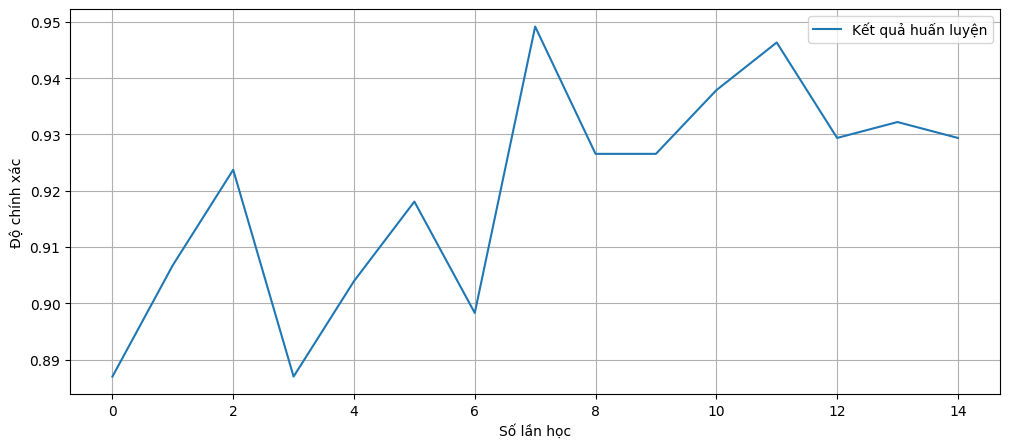

In [40]:
#biên dịch
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=['accuracy'])
#Tóm tắt cấu hình của mô hình
model.summary()
#Huấn luyện mô hình CNN
epochs=15
history=model.fit(train_generator, steps_per_epoch=32, epochs=epochs)
#Đánh giá kqua mô hình
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'],label='Kết quả huấn luyện')
#plt.plot(history.history['val_accuracy'],label='Độ chính xác xác thực')
plt.xlabel('Số lần học')
plt.ylabel('Độ chính xác')
plt.legend()
plt.grid(True)
plt.show()

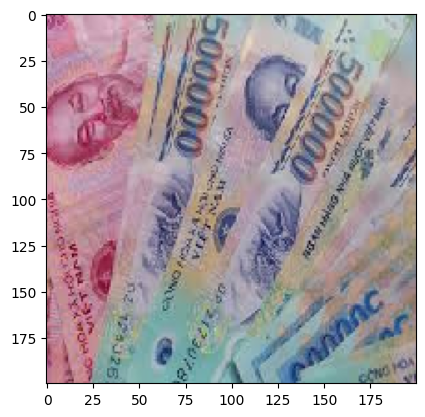

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Dự đoán số tiền: 500k


In [53]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path = "/content/tiền.jfif"

# Tiên đoán loại s
img = load_img(path, target_size=(200,200))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 200, 200, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
banknote_name = class_labels[prediction]
print(f"Dự đoán số tiền: {banknote_name}")
